In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("C:/Users/HP EliteBook/Downloads/Diabetes_Model.csv")
df

,Age,BMI,Glucose,Blood_Pressure,Insulin,Cholesterol_Level,Skin_Thickness,Pregnancies,Physical_Activity,SleepHours,Gender,Family_History,Smoking_Status,Diet_Type,Exercise_Level,Diabetes_Status
0,58,26.96,243.06,90.99,129.87,320.86,28.71,0,0.00,7.63,Male,No,No,Good,Low,Yes
1,71,23.65,195.77,66.69,85.41,270.36,34.74,9,0.54,6.26,Female,No,No,Average,Low,No
2,48,29.36,148.62,81.49,98.00,255.58,25.61,0,0.00,7.17,Female,Yes,Yes,NaN,High,Yes
3,34,24.81,230.87,102.01,142.97,294.39,26.18,8,0.00,6.38,Male,No,Yes,Average,Low,No
4,62,28.81,206.79,103.88,130.91,273.28,33.36,3,0.00,6.65,Female,Yes,No,Average,Medium,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,61,17.40,202.63,83.12,104.62,291.25,25.15,5,1.12,7.03,Male,No,No,Good,Medium,No
14996,30,32.62,125.33,78.07,74.55,242.59,25.05,3,1.53,7.16,Male,No,Yes,NaN,Medium,No
14997,48,29.06,230.01,91.48,124.11,275.92,27.48,2,0.00,4.40,Male,No,No,Good,Low,Yes
14998,36,23.78,159.98,98.44,85.37,251.63,26.94,3,0.34,6.93,Male,No,No,Good,Low,No


In [5]:
df.shape

(15000, 16)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                15000 non-null  int64  
 1   BMI                15000 non-null  float64
 2   Glucose            15000 non-null  float64
 3   Blood_Pressure     15000 non-null  float64
 4   Insulin            15000 non-null  float64
 5   Cholesterol_Level  15000 non-null  float64
 6   Skin_Thickness     15000 non-null  float64
 7   Pregnancies        15000 non-null  int64  
 8   Physical_Activity  15000 non-null  float64
 9   SleepHours         15000 non-null  float64
 10  Gender             15000 non-null  object 
 11  Family_History     15000 non-null  object 
 12  Smoking_Status     15000 non-null  object 
 13  Diet_Type          13950 non-null  object 
 14  Exercise_Level     14100 non-null  object 
 15  Diabetes_Status    15000 non-null  object 
dtypes: float64(8), int64(2

In [7]:
df.dtypes

Age                    int64
BMI                  float64
Glucose              float64
Blood_Pressure       float64
Insulin              float64
Cholesterol_Level    float64
Skin_Thickness       float64
Pregnancies            int64
Physical_Activity    float64
SleepHours           float64
Gender                object
Family_History        object
Smoking_Status        object
Diet_Type             object
Exercise_Level        object
Diabetes_Status       object
dtype: object

In [2]:
df.isnull().sum()

Age                     0
BMI                     0
Glucose                 0
Blood_Pressure          0
Insulin                 0
Cholesterol_Level       0
Skin_Thickness          0
Pregnancies             0
Physical_Activity       0
SleepHours              0
Gender                  0
Family_History          0
Smoking_Status          0
Diet_Type            1050
Exercise_Level        900
Diabetes_Status         0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.describe()

,Age,BMI,Glucose,Blood_Pressure,Insulin,Cholesterol_Level,Skin_Thickness,Pregnancies,Physical_Activity,SleepHours
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,49.559400,27.987067,190.046525,90.733707,104.13124,285.734083,27.774722,4.869867,0.212421,6.442223
std,17.287375,4.931577,33.012187,11.377033,24.86553,29.889875,4.833085,2.922699,0.521789,0.857578
min,20.000000,15.000000,65.450000,47.950000,10.41000,179.770000,10.570000,0.000000,0.000000,3.320000
25%,35.000000,24.590000,168.215000,83.000000,87.34750,265.395000,24.530000,2.000000,0.000000,5.860000
50%,49.000000,27.970000,190.125000,90.870000,104.17000,285.580000,27.750000,5.000000,0.000000,6.430000
75%,65.000000,31.330000,212.320000,98.280000,121.00000,306.172500,31.040000,7.000000,0.000000,7.020000
max,79.000000,47.510000,316.630000,133.700000,206.29000,403.160000,46.860000,10.000000,4.590000,10.120000


In [11]:
df['Diet_Type'].value_counts()

Diet_Type
Average    5618
Poor       4746
Good       3586
Name: count, dtype: int64

In [12]:
df['Exercise_Level'].value_counts()

Exercise_Level
Low       6892
Medium    4849
High      2359
Name: count, dtype: int64

# #First Steps Data Cleaning of Diabetes

# #Add the Missing values

Some Missing_Values in the Diet_Type and Exercise_Level Columns Not Match the Diabetes Dataset

In [17]:
df['Diet_Type'] = df['Diet_Type'].fillna(df['Diet_Type'].mode()[0])
df['Exercise_Level'] = df['Exercise_Level'].fillna(df['Exercise_Level'].mode()[0])

 Mode imputation fills missing values in categorical columns using the most frequently occurring value in that column.
 
 like in this columns Missing Values
 
 Diet_Type (1050) 
 
 Exercise_Level (900)

In [18]:
df.isnull().sum()

Age                  0
BMI                  0
Glucose              0
Blood_Pressure       0
Insulin              0
Cholesterol_Level    0
Skin_Thickness       0
Pregnancies          0
Physical_Activity    0
SleepHours           0
Gender               0
Family_History       0
Smoking_Status       0
Diet_Type            0
Exercise_Level       0
Diabetes_Status      0
dtype: int64

# #Exploratory Data Analysis(EDA)

# Univeriate single Variable

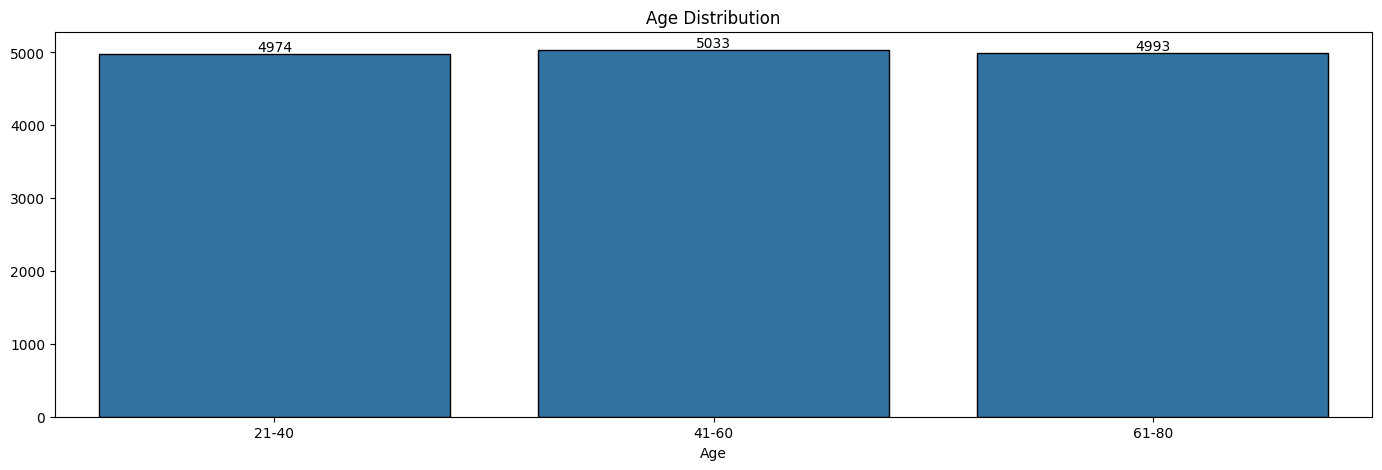

In [209]:
bins = [20, 40, 60, 80]   
labels = ['21-40', '41-60', '61-80']
Count = df.groupby(pd.cut(df['Age'], bins=bins, labels=labels, right=False)).size()
plt.figure(figsize=(17,5))
ax = sns.barplot(x=Count.index,y=Count.values,color=('#1f76b5'),edgecolor="black",legend=False)
for count in ax.containers:
   ax.bar_label(count)
plt.title('Age Distribution')
plt.show()

How ages are distributed across two groups.

All three age groups are nearly equally represented (~5,000 each), with the 41–60 group slightly leading at 5,033. 

The minimal difference of just 59 records across groups confirms a well-balanced dataset

# #Find the Distribution of Fasting Blood Sugar by Diabetes Status

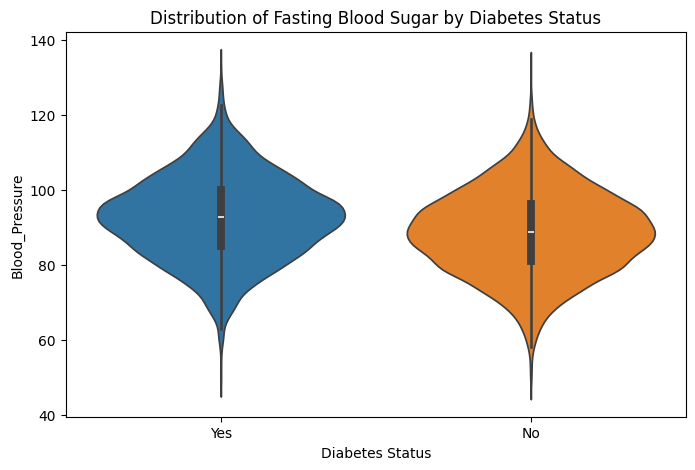

In [104]:
plt.figure(figsize=(8,5))
sns.violinplot(x='Diabetes_Status', y='Blood_Pressure', data=df,hue='Diabetes_Status')
plt.title('Distribution of Fasting Blood Sugar by Diabetes Status')
plt.xlabel('Diabetes Status')
plt.ylabel('Blood_Pressure')
plt.show()

Diabetic patients (Yes) show a slightly higher and more concentrated blood pressure distribution centered around 90–95, 

while non-diabetics (No) are centered slightly lower around 85–90 with a wider, flatter spread. 

Both groups share a similar overall range (~55–138), but the diabetic group's denser mid-section 

suggests consistently elevated blood pressure is more common among diabetics — 

pointing to blood pressure as a potentially meaningful feature for diabetes prediction.

# #Find the Percentage of Distribution And Diabetes_Status

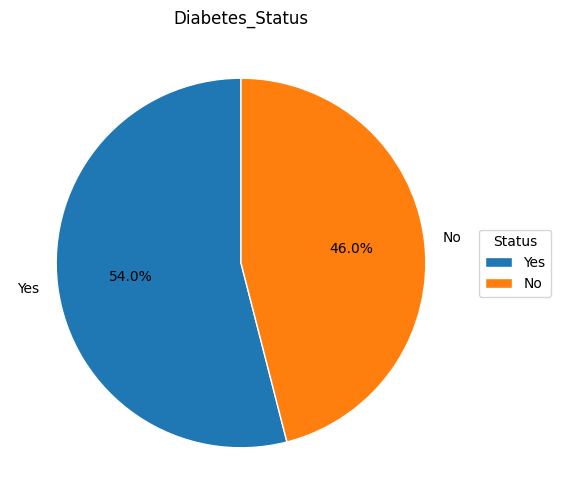

In [105]:
count = df['Diabetes_Status'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(count,
        labels=count.index,
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'edgecolor': 'white'}) 
plt.title('Diabetes_Status')
plt.legend(title="Status", loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()

Distribution

Diabetes_Status:

       Yes: 54.0%

       No: 46.0%

The dataset shows a mild class imbalance with 54% diabetic (Yes) and 46% non-diabetic (No) cases

# #Biveriate Two Variable

Find the Distribution Gender on Diebetes_Status

# Gender and Family_History Count by Diabetes

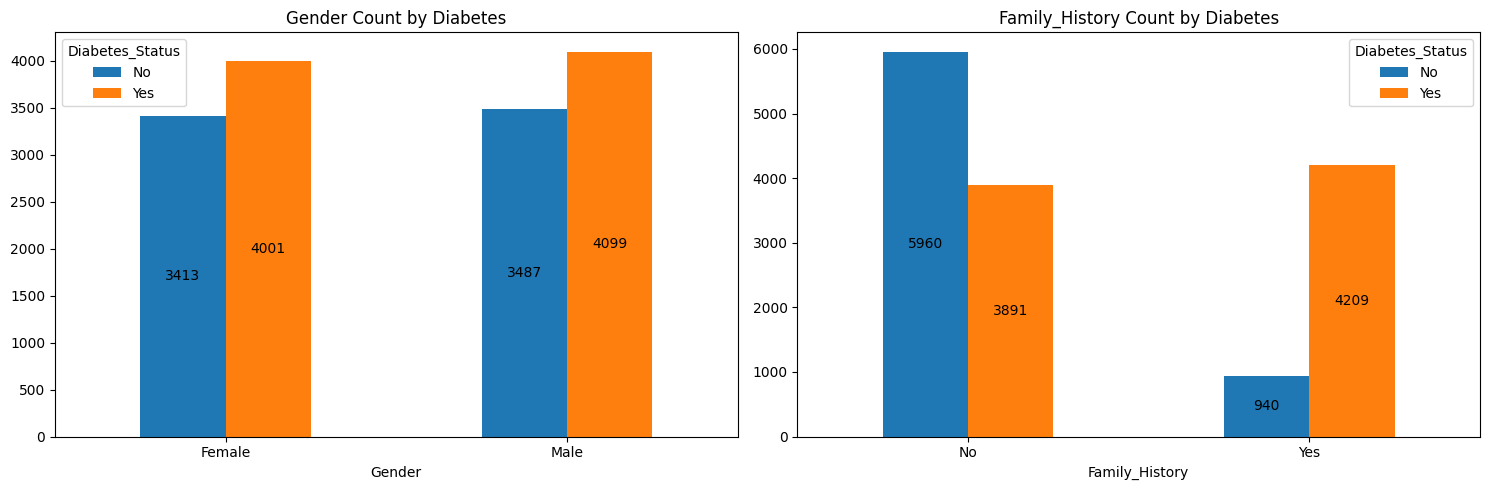

In [106]:
count = df.groupby(['Gender','Diabetes_Status']).size().unstack(fill_value=0)
counts = df.groupby(['Family_History','Diabetes_Status']).size().unstack(fill_value=0)
fig, axes = plt.subplots(1,2,figsize=(15,5))
num = count.plot(kind="bar",ax=axes[0])
nums = counts.plot(kind="bar",ax=axes[1])
for x in num.containers:
  num.bar_label(x,label_type='center')
for ax in nums.containers:
  nums.bar_label(ax,label_type='center')
axes[0].tick_params(axis='x',rotation=0)
axes[0].set_title('Gender Count by Diabetes')
axes[1].set_title('Family_History Count by Diabetes')
axes[1].tick_params(axis='x',rotation=0)
plt.tight_layout()
plt.show()

Gender: Diabetes (Yes) outnumbers non-diabetes (No) in both sexes — females (4,001 vs 3,413) and males (4,099 vs 3,487) — with a similar gap across genders, suggesting gender alone is not a strong differentiator for diabetes risk.

Family History: This is a far stronger signal. Among those with family history, diabetics heavily outnumber non-diabetics (4,209 vs 940), nearly a 4.5:1 ratio — while those without family history are predominantly non-diabetic (5,960 vs 3,891). This makes family history one of the most discriminating features for diabetes prediction.

# Smoking_Status and Physical_Activity Count by Diabetes

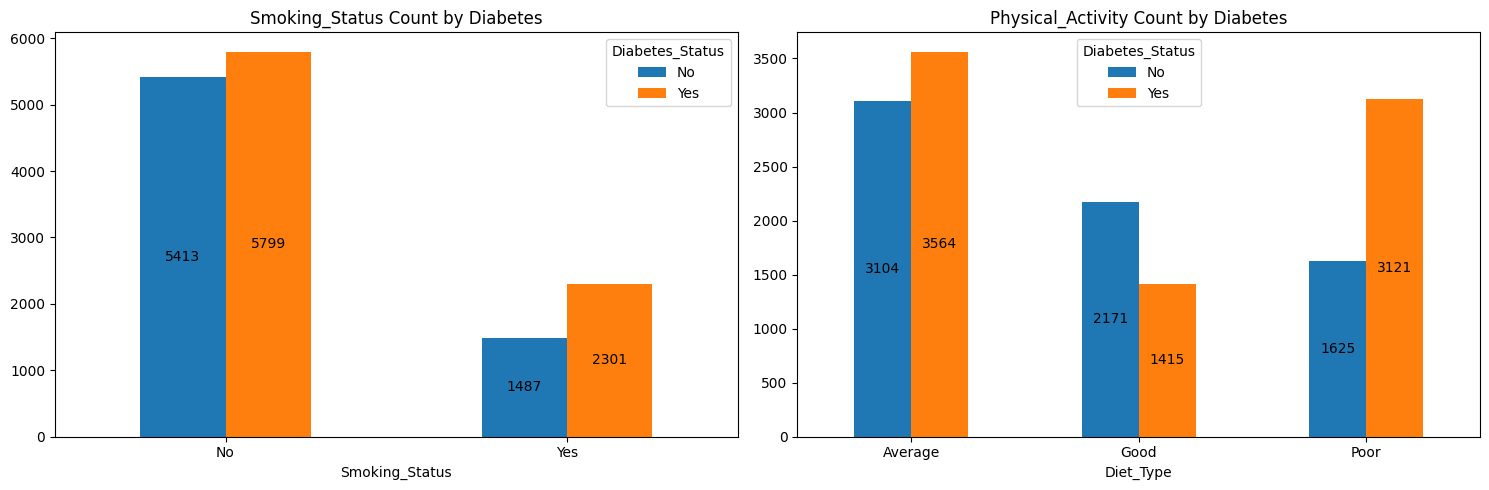

In [107]:
count = df.groupby(['Smoking_Status','Diabetes_Status']).size().unstack(fill_value=0)
counts = df.groupby(['Diet_Type','Diabetes_Status']).size().unstack(fill_value=0)
fig, axes = plt.subplots(1,2,figsize=(15,5))
num = count.plot(kind="bar",ax=axes[0])
nums = counts.plot(kind="bar",ax=axes[1])
for x in num.containers:
  num.bar_label(x,label_type="center")
plt.xticks(rotation=0)
for y in nums.containers:
  nums.bar_label(y,label_type='center')
axes[0].set_title('Smoking_Status Count by Diabetes')
axes[0].tick_params(axis='x',rotation=0)
axes[1].set_title('Diet_Type Count by Diabetes')
axes[1].tick_params(axis='x',rotation=0)
plt.tight_layout()
plt.show()

Smoking Status: Diabetics outnumber non-diabetics in both smokers (2,301 vs 1,487) and non-smokers (5,799 vs 5,413), but the gap is notably wider among smokers, suggesting smoking amplifies diabetes risk.

Diet Type: A good diet shows the strongest protective effect — non-diabetics nearly double diabetics (2,171 vs 1,415). In contrast, average and poor diets 
both show diabetics outnumbering non-diabetics, with poor diet (3,121 vs 1,625) being the most concerning pattern. This makes diet quality a meaningful predictor, where better eating habits correlate clearly with lower diabetes prevalence.

# Exercise_Level Count by Diabetes

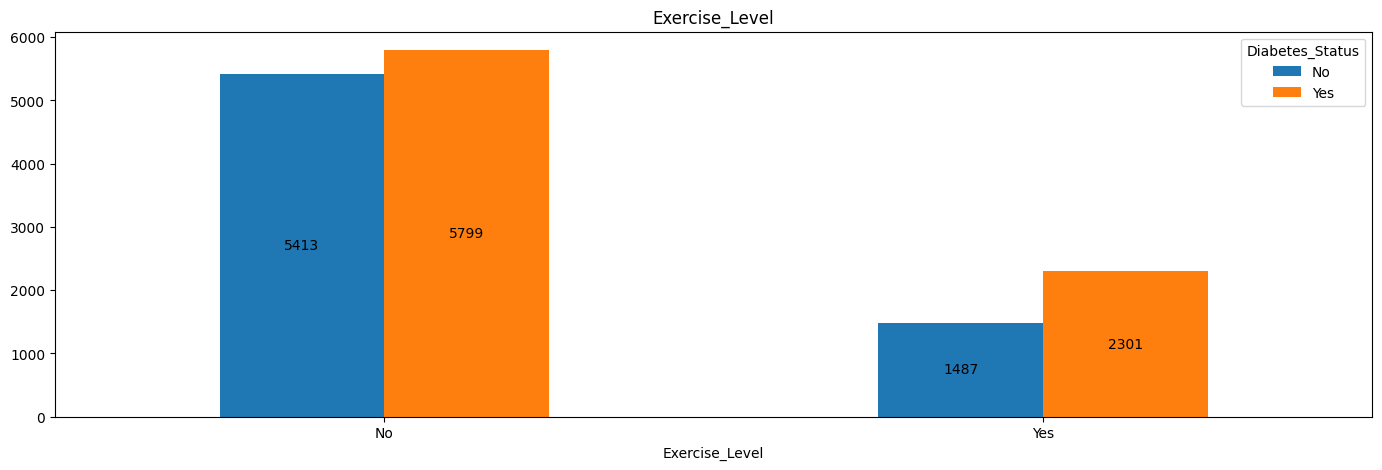

In [110]:
counts = df.groupby(['Exercise_Level','Diabetes_Status']).size().unstack(fill_value=0)
num = count.plot(kind="bar",figsize=(17,5))
for x in num.containers:
  num.bar_label(x,label_type="center")
plt.xticks(rotation=0)
plt.title("Exercise_Level")
plt.xlabel("Exercise_Level")
plt.show()

Diabetics outnumber non-diabetics regardless of exercise level — low/no exercise (5,799 vs 5,413) and active (2,301 vs 1,487). 

However, the gap is notably wider among those who do exercise, where diabetics exceed non-diabetics by ~55% compared to only ~7% among non-exercisers.

This counterintuitive pattern suggests that exercise alone does not prevent diabetes

# Age Count by Diabetes

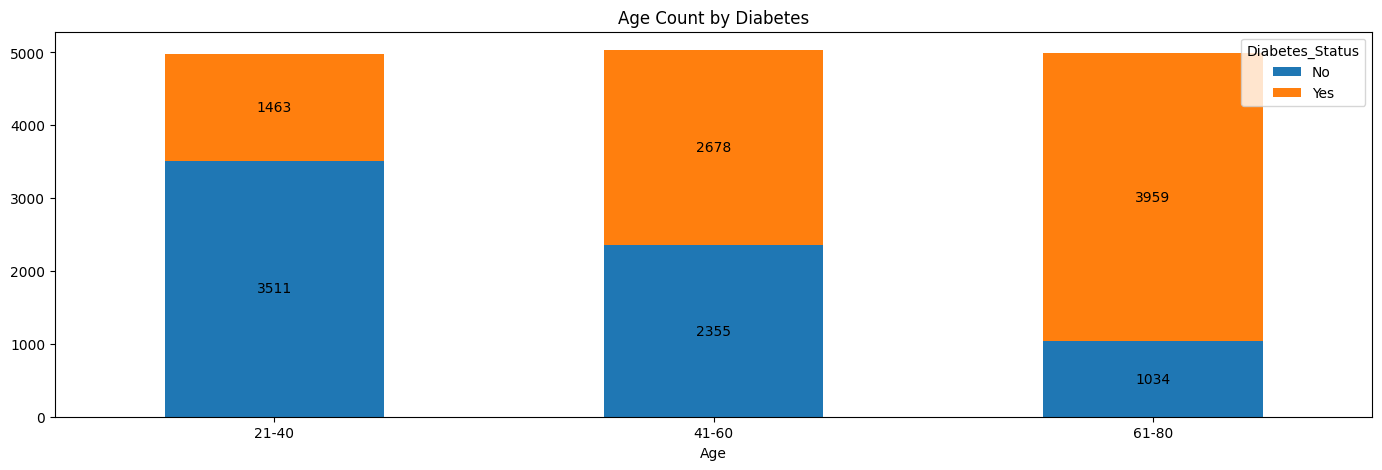

In [111]:
bins = [20, 40, 60, 80]
labels = ['21-40', '41-60', '61-80']
count = df.groupby([pd.cut(df['Age'], bins=bins, labels=labels, right=False),"Diabetes_Status"]).size().unstack(fill_value=0)
ax = count.plot(kind="bar",stacked=True,figsize=(17,5))
for x in ax.containers:
  ax.bar_label(x,label_type="center")
plt.xticks(rotation=0)
plt.title('Age Count by Diabetes')
plt.show()

Age is a strong and progressive diabetes risk factor. 

The youngest group (21–40) is predominantly non-diabetic (3,511 vs 1,463), the middle group (41–60) becomes nearly split (2,355 vs 2,678), and the oldest group (61–80) is overwhelmingly diabetic (3,959 vs 1,034). 

This clear age-driven escalation makes age one of the most powerful predictors in the dataset.

# Blood_Pressure Count by Diabetes

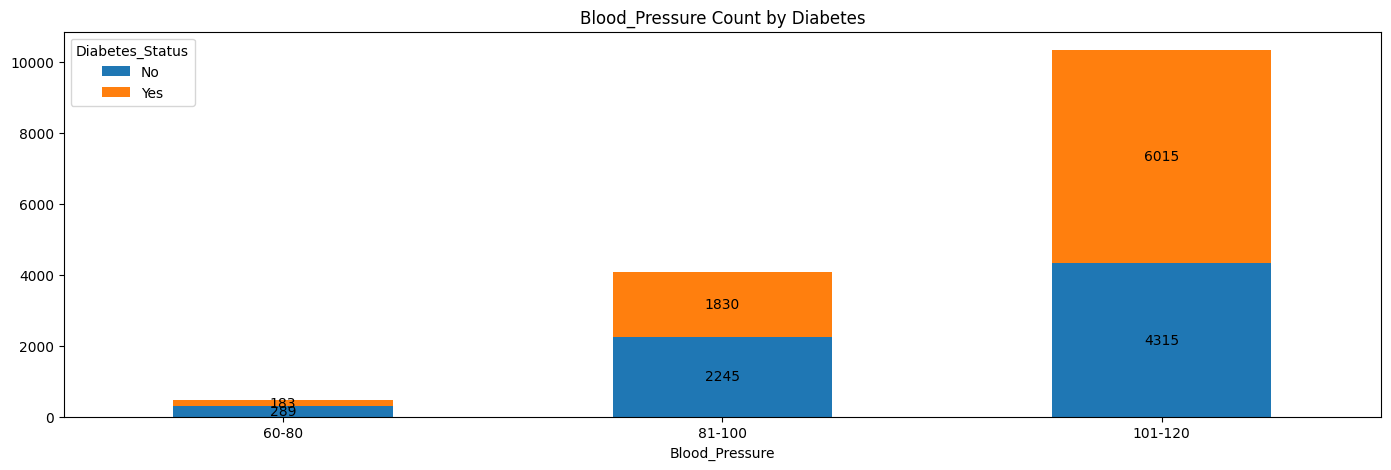

In [113]:
bins = [60,70,85,120]
labels = ['60-80','81-100','101-120']
count  = df.groupby([pd.cut(df['Blood_Pressure'], bins=bins, labels=labels, right=False),'Diabetes_Status']).size().unstack(fill_value=0)
ax = count.plot(kind="bar",stacked=True,figsize=(17,5))
for x in ax.containers:
  ax.bar_label(x,label_type="center")
plt.xticks(rotation=0)
plt.title('Blood_Pressure Count by Diabetes')
plt.show()

Blood pressure shows a clear escalating relationship with diabetes. 

In the normal range (60–80), non-diabetics slightly dominate (289 vs 183).

The elevated range (81–100) becomes more balanced but still non-diabetic-leaning (2,245 vs 1,830). 

However, in the high range (101–120), diabetics surge to 6,015 vs 4,315 non-diabetics — making high blood pressure the dominant pattern among diabetics and confirming it as a significant risk indicator.

# BMI Count by Diabetes

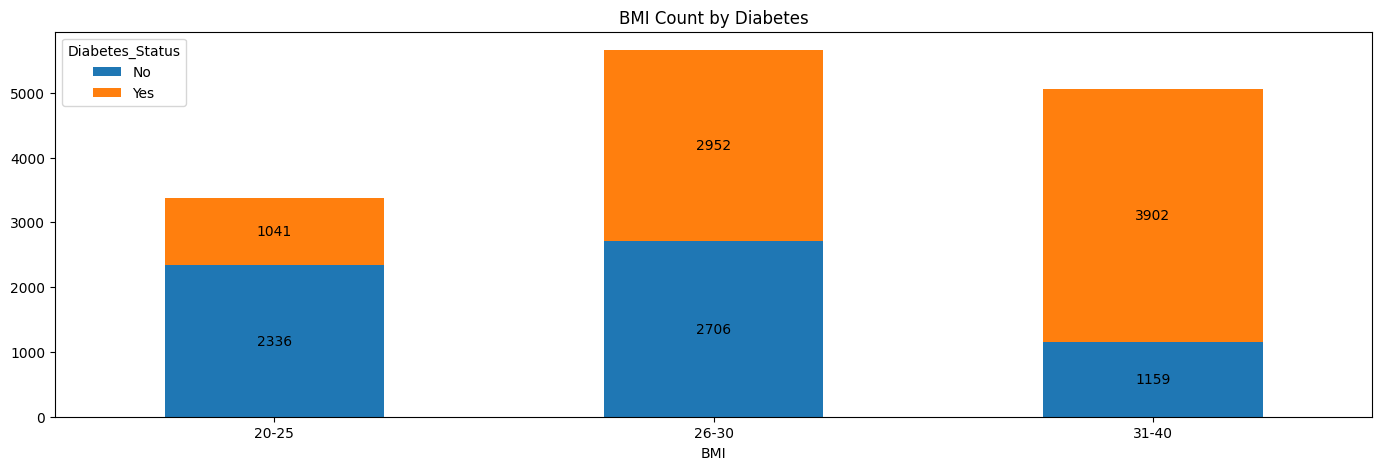

In [114]:
bins = [20,25,30,40]
labels = ['20-25','26-30','31-40']
count =df.groupby([pd.cut(df['BMI'], bins=bins, labels=labels, right=False),'Diabetes_Status']).size().unstack(fill_value=0)
ax = count.plot(kind="bar",stacked=True,figsize=(17,5))
for x in ax.containers:
  ax.bar_label(x,label_type="center")
plt.xticks(rotation=0)
plt.title('BMI Count by Diabetes')
plt.show()

BMI reveals a strong and progressive diabetes risk pattern. 

In the healthy range (20–25), non-diabetics lead (2,336 vs 1,041). 

The overweight range (26–30) becomes more competitive but still non-diabetic-leaning (2,706 vs 2,952 — nearly equal). 

In the obese range (31–40), diabetics overwhelmingly dominate (3,902 vs 1,159) — a ratio of over 3:1. 

This clear escalation makes BMI one of the strongest and most actionable predictors of diabetes in the dataset.

# Pregnancies Count by Diabetes

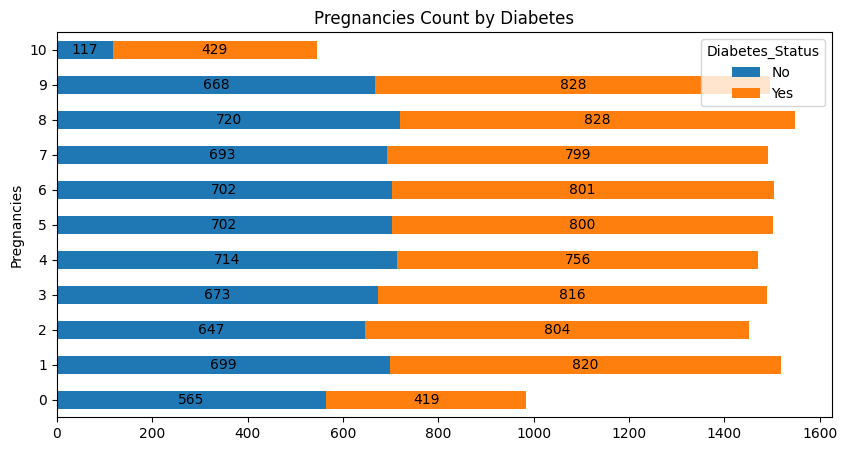

In [3]:
count = df.groupby(['Pregnancies','Diabetes_Status']).size().unstack(fill_value=0)
ax = count.plot(kind="barh",stacked=True,figsize=(10,5))
for x in ax.containers:
  ax.bar_label(x,label_type="center")
plt.xticks(rotation=0)
plt.title('Pregnancies Count by Diabetes')
plt.show()

Pregnancy count shows a nuanced pattern. 

At 0 pregnancies, non-diabetics lead (565 vs 419), and at 4 pregnancies non-diabetics are closest to parity (714 vs 756). 

However, across most pregnancy counts (1–3, 5–10), diabetics consistently and significantly outnumber non-diabetics, with the gap widening at higher counts — particularly at 10 pregnancies (429 vs 117), a nearly 4:1 diabetic ratio. 

This suggests higher pregnancy count is a meaningful escalating risk factor for diabetes.

# #Lineplot and ScatterScatterplot on Age and Heart_Rate

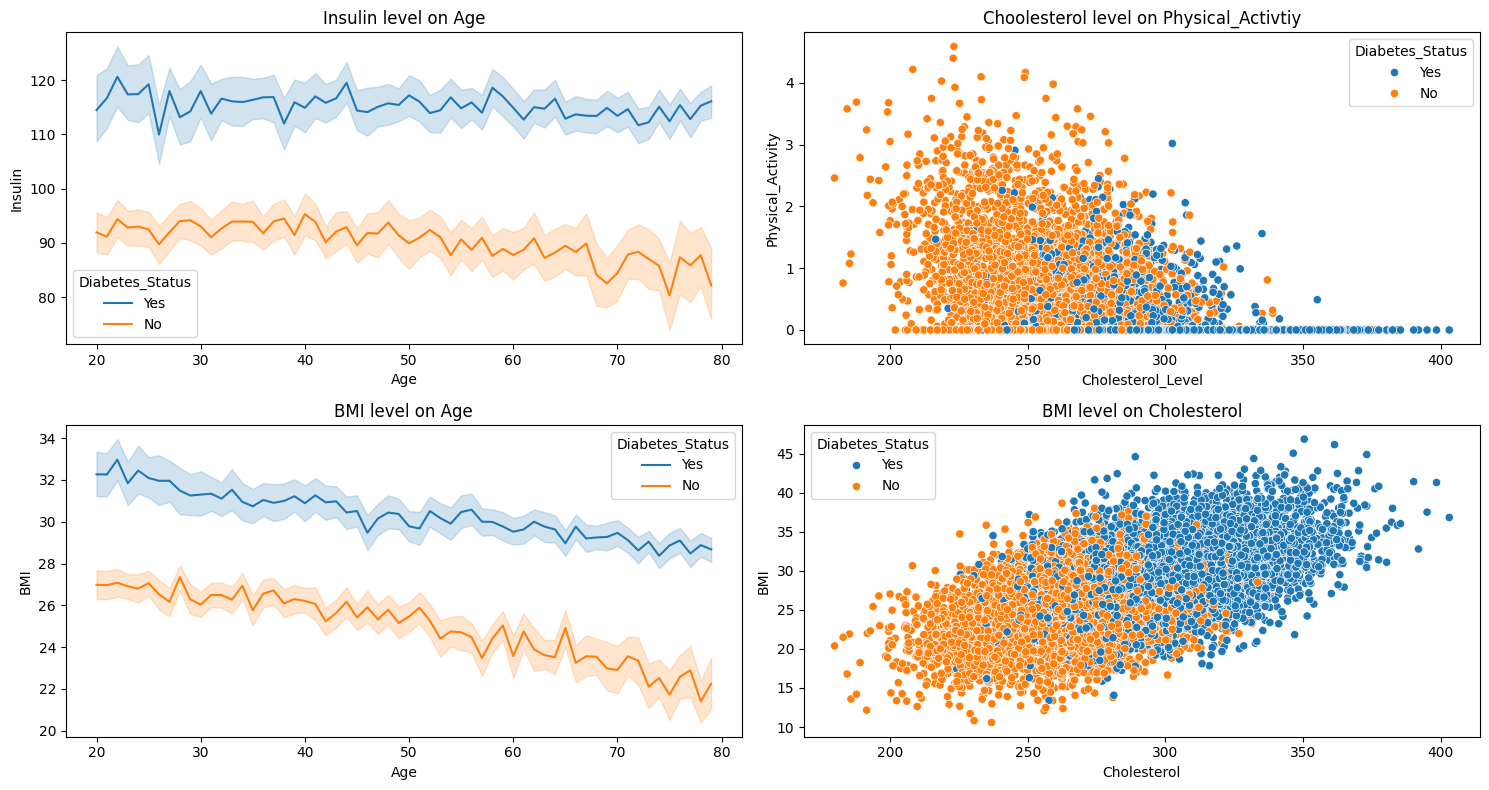

In [117]:
fig, axes = plt.subplots(2,2,figsize=(15,8))
axes = axes.flatten()
df_sorted = df.sort_values(by="Age")
sns.lineplot( data=df_sorted,x='Age',y='Insulin',hue="Diabetes_Status",ax=axes[0])
sns.scatterplot(data=df,x='Cholesterol_Level',y='Physical_Activity',hue="Diabetes_Status",ax=axes[1])
sns.lineplot(data=df_sorted,x='Age', y='BMI',hue="Diabetes_Status",ax=axes[2])
sns.scatterplot(data=df,x='Cholesterol_Level', y='Skin_Thickness',hue="Diabetes_Status",ax=axes[3])
axes[0].set_title('Insulin level on Age')
axes[1].set_title('Choolesterol level on Physical_Activtiy')
axes[2].set_title('BMI level on Age')
axes[3].set_title('BMI level on Cholesterol')
plt.xlabel('Cholesterol')
plt.ylabel('BMI')
plt.tight_layout()
plt.show()

Insulin vs Age: 

Diabetics maintain consistently higher insulin levels (115–120) across all age groups compared to non-diabetics (85–95), with the gap remaining stable throughout life. 

This persistent separation makes insulin level a highly reliable and age-independent diabetes predictor.

Cholesterol vs Physical Activity: 

Non-diabetics (orange) are broadly distributed across all cholesterol levels with higher physical activity, while diabetics (blue) cluster heavily at lower physical activity levels (0–1) and tend toward higher cholesterol (280–400). 

This suggests that the combination of low activity and high cholesterol is a strong dual risk signal for diabetes.

BMI vs Age:

Diabetics start with significantly higher BMI (32) in their 20s and decline gradually with age, while non-diabetics begin lower (27) and also decline, reaching 22 by age 80. 

The gap between the two groups remains consistent throughout, confirming BMI as a stable, age-independent diabetes differentiator.

BMI vs Cholesterol: 

Diabetics (blue) cluster at higher BMI (28–45) and higher cholesterol (270–400), while non-diabetics (orange) concentrate at lower BMI (10–30) and lower cholesterol (180–280). 

The two groups show clear spatial separation, indicating that the combination of elevated BMI and high cholesterol together forms a powerful joint risk profile for diabetes.

# #Find the Correlation between together Every Variables

# Heatmap Correlation

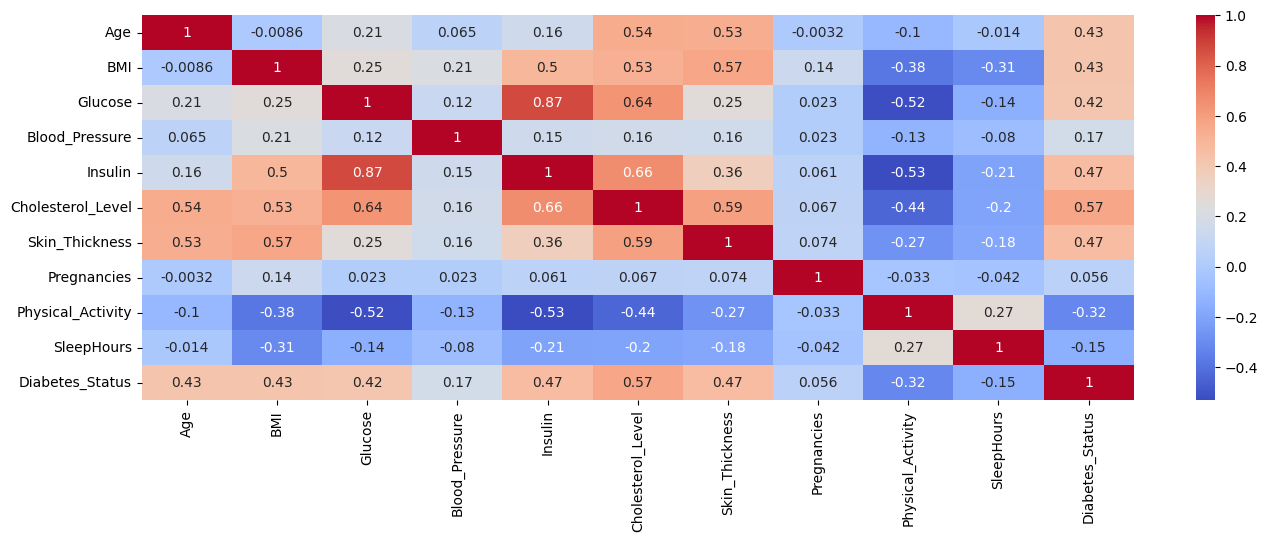

In [187]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(16,5))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.show()

Top predictors of Diabetes_Status:

Cholesterol_Level (0.57) — strongest positive predictor; higher cholesterol strongly associates with diabetes

Insulin (0.47) & Skin_Thickness (0.47) — elevated levels closely tied to diabetic status

Age (0.43) & BMI (0.43) — confirm earlier findings; older age and higher BMI consistently drive diabetes risk

Glucose (0.42) — moderately strong, expected clinical marker

Physical_Activity (−0.32) — the strongest protective factor; more activity meaningfully reduces diabetes likelihood

Blood_Pressure (0.17) & Pregnancies (0.056) — weakest direct correlations with diabetes

SleepHours (−0.15) — slight negative association, more sleep marginally protective

Notable inter-feature relationships: 
Glucose–Insulin (0.87) is the strongest pair in the matrix,

followed by Cholesterol–Insulin (0.66) and Cholesterol–Glucose (0.64)

suggesting multicollinearity that may need addressing in linear models.

# #Find the Normal Distribution of Each Columns to Predict the Machine Learning Model

# Normal Distribution Histogram plot

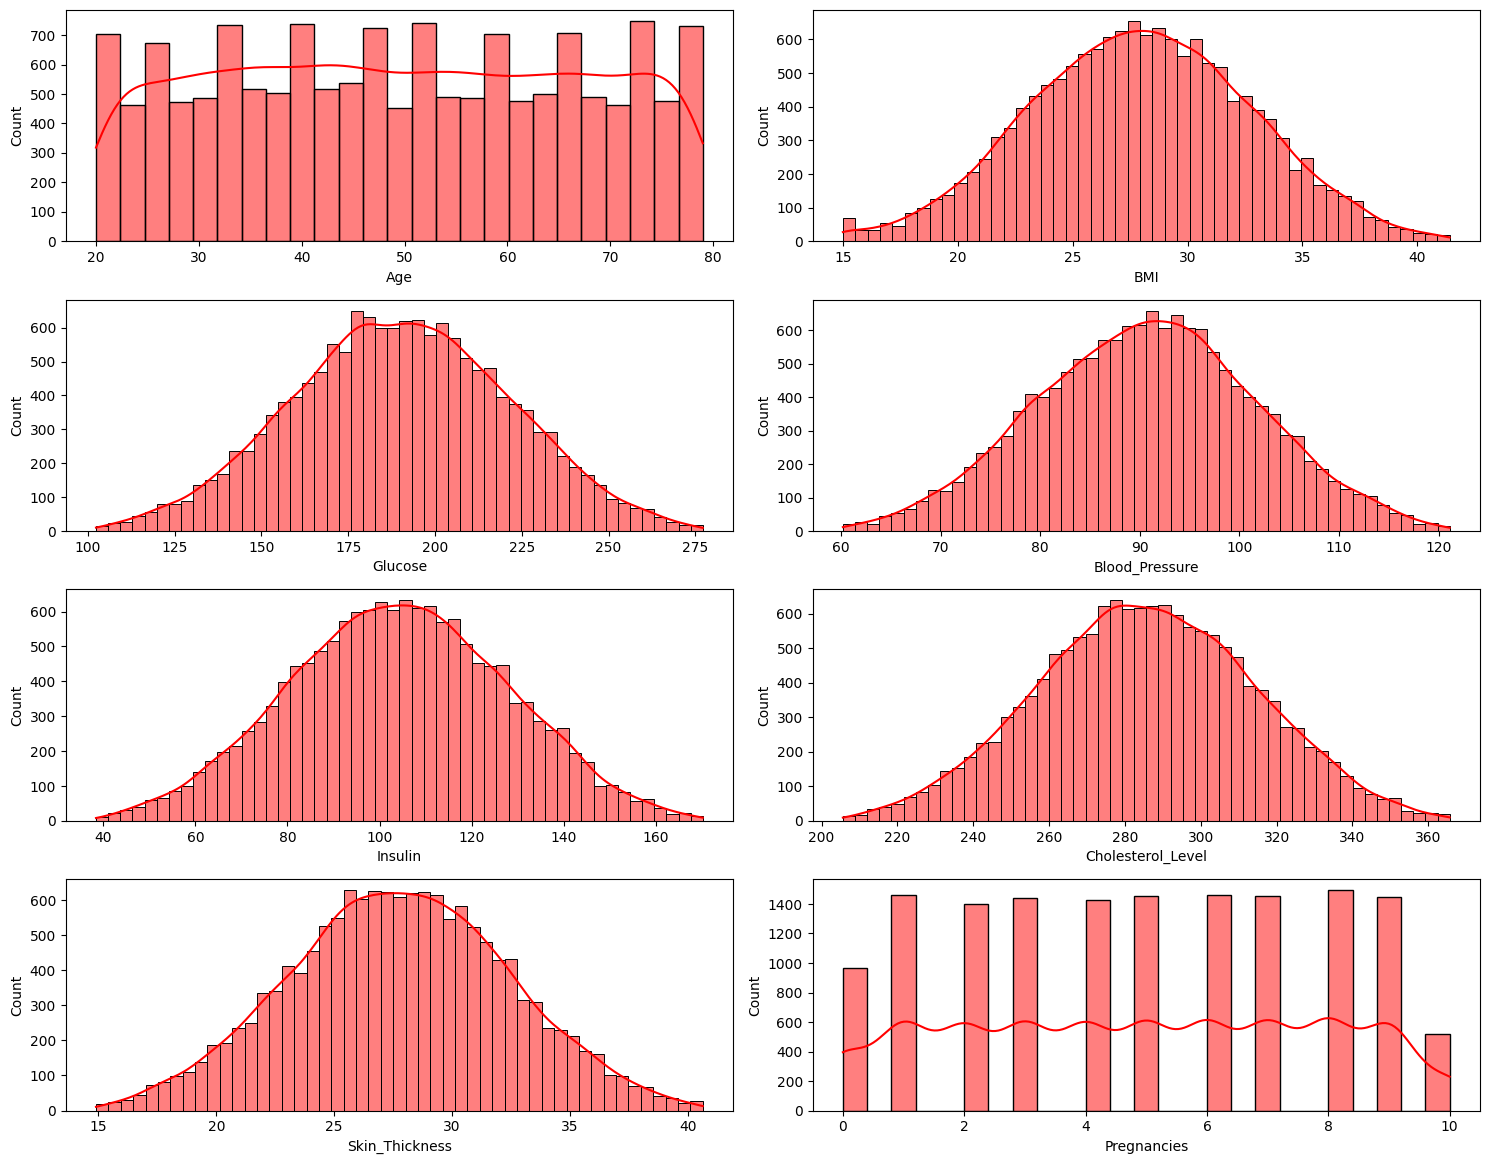

In [212]:
def plotting(var,num):
    plt.subplot(7,2,num)
    sns.histplot(df_clean[var],kde=True,color='red')
plt.figure(figsize=(15,20))
plotting('Age',1)
plotting('BMI',2)
plotting('Glucose',3)
plotting('Blood_Pressure',4)
plotting('Insulin',5)
plotting('Cholesterol_Level',6)
plotting('Skin_Thickness',7)
plotting('Pregnancies',8)
plt.tight_layout()
plt.show()

# Normal Distribution Boxplot To Find the Outliers

# Boxplot

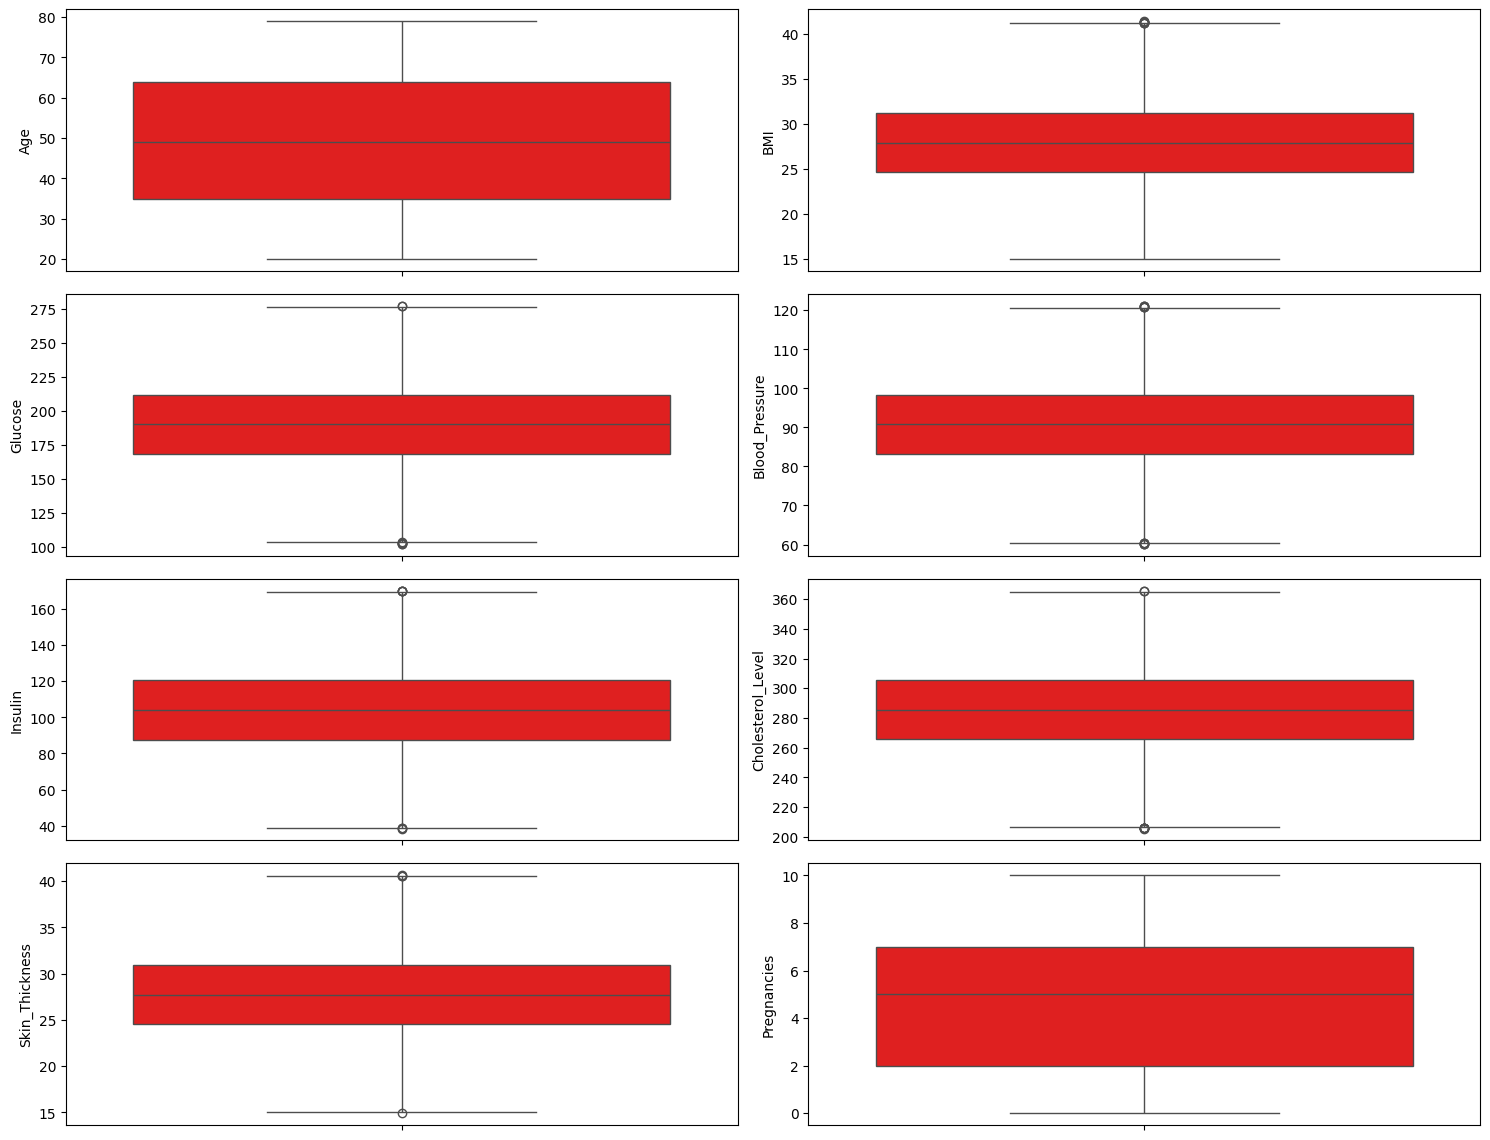

In [20]:
def plotting(var,num):
    plt.subplot(7,2,num)
    sns.boxplot(df_clean[var],color="red")
plt.figure(figsize=(15,20))
plotting('Age',1)
plotting('BMI',2)
plotting('Glucose',3)
plotting('Blood_Pressure',4)
plotting('Insulin',5)
plotting('Cholesterol_Level',6)
plotting('Skin_Thickness',7)
plotting('Pregnancies',8)
plt.tight_layout()
plt.show()

# Remove Outliers Use IQR Method

In [19]:
Columns = ['BMI','Glucose','Blood_Pressure','Insulin','Cholesterol_Level','Skin_Thickness']   # example variables

df_clean = df.copy()

for col in Columns:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Filter out outliers for this column
    df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

# Feature Engineering for ML Model

### Label Encoding of Output Variable like Diabetes Status


In [33]:
df_clean['Exercise_Level'].value_counts()

Exercise_Level
1    7566
2    4687
3    2276
Name: count, dtype: int64

In [30]:
df_clean['Diabetes_Status'] = df_clean['Diabetes_Status'].map({'No':0,'Yes':1}).astype(int)

In [31]:
df_clean['Exercise_Level'] = df_clean['Exercise_Level'].map({'Low':1,'Medium':2,'High':3}).astype(int)

In [32]:
df_clean['Diabetes_Status'].unique()

array([1, 0])

# One Hot Encoding 

### Features of Nominal Categorical    Nominal Columns

In [24]:
df_clean = pd.get_dummies(df,
                    columns=['Gender','Family_History',
                             'Diet_Type','Smoking_Status'],
                    drop_first=True,dtype=int
                   )

In [40]:
df_clean.dtypes

Age                     int64
BMI                   float64
Glucose               float64
Blood_Pressure        float64
Insulin               float64
Cholesterol_Level     float64
Skin_Thickness        float64
Pregnancies             int64
Physical_Activity     float64
SleepHours            float64
Exercise_Level          int64
Diabetes_Status         int64
Gender_Male             int64
Family_History_Yes      int64
Diet_Type_Good          int64
Diet_Type_Poor          int64
Smoking_Status_Yes      int64
dtype: object

# Data Train Test Split for the ML Model

In [41]:
from sklearn.model_selection import train_test_split
X = df_clean.drop('Diabetes_Status',axis=1)
y = df_clean['Diabetes_Status']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

In [42]:
X_train.shape

(12000, 16)

In [43]:
y_train.shape

(12000,)

# Standardization Method for Logistics Regression 

### Rescalling Values Between Mean and Standard Deviation 0 and 1

In [44]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Standarize the Data to Become Numpy Array

In [45]:
X_train_scaled

array([[-0.49646023,  0.71399008,  0.34710688, ...,  1.77101797,
        -0.67878019, -0.57940308],
       [-0.43861065, -1.76468628, -1.25570865, ..., -0.56464701,
        -0.67878019, -0.57940308],
       [-0.09151321,  2.11128313,  1.09243282, ..., -0.56464701,
        -0.67878019,  1.7259142 ],
       ...,
       [-1.36420384, -1.10249088,  0.12034785, ...,  1.77101797,
        -0.67878019, -0.57940308],
       [ 0.83407998,  0.23607536,  1.03802281, ..., -0.56464701,
         1.47323098, -0.57940308],
       [ 0.48698254,  1.2567068 , -0.02099659, ..., -0.56464701,
        -0.67878019, -0.57940308]], shape=(12000, 16))

### Numpy Array to convert in the Orignal Dataframe

In [46]:
X_train_scaled = pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,columns=X_train.columns)

In [47]:
X_test_scaled

,Age,BMI,Glucose,Blood_Pressure,Insulin,Cholesterol_Level,Skin_Thickness,Pregnancies,Physical_Activity,SleepHours,Exercise_Level,Gender_Male,Family_History_Yes,Diet_Type_Good,Diet_Type_Poor,Smoking_Status_Yes
0,0.776230,0.922572,0.928595,1.341835,1.456067,-0.159375,0.872727,-0.630911,-0.404304,1.443736,-0.861227,-1.013254,-0.722811,-0.564647,-0.678780,-0.579403
1,1.643974,-0.827082,-0.040754,0.302532,-0.417246,0.169908,0.169340,1.079338,-0.404304,0.139317,-0.861227,-1.013254,-0.722811,-0.564647,-0.678780,1.725914
2,1.181177,0.952947,0.296648,-0.030185,0.725608,1.136673,-0.426470,1.763437,-0.404304,1.362210,-0.861227,-1.013254,1.383487,1.771018,-0.678780,-0.579403
3,0.834080,1.125078,1.444122,0.144929,0.945310,2.127197,2.134686,-1.315010,-0.404304,-1.491207,-0.861227,-1.013254,-0.722811,-0.564647,1.473231,1.725914
4,-1.711301,-0.085910,0.352882,0.745571,0.149142,-0.882525,-1.307772,1.421388,-0.404304,-0.245021,-0.861227,0.986919,-0.722811,-0.564647,1.473231,1.725914
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,-0.033664,-1.778862,-0.103675,-0.099355,-1.263805,-0.715876,-0.635417,-1.657060,-0.404304,0.267429,-0.861227,-1.013254,-0.722811,1.771018,-0.678780,-0.579403
2996,-1.537753,2.157860,1.464792,1.579990,1.876121,0.520272,0.566547,-0.972960,-0.404304,0.418835,-0.861227,-1.013254,1.383487,-0.564647,-0.678780,1.725914
2997,-1.479903,-0.989087,-1.970638,-1.291008,-1.494391,-2.324474,-1.702910,-0.972960,0.786171,-0.943817,0.488130,-1.013254,-0.722811,-0.564647,-0.678780,-0.579403
2998,0.834080,2.801829,0.509425,-2.606991,0.934426,2.148948,2.794629,1.763437,-0.404304,-0.477953,-0.861227,0.986919,-0.722811,-0.564647,1.473231,-0.579403


In [48]:
X_train_scaled

,Age,BMI,Glucose,Blood_Pressure,Insulin,Cholesterol_Level,Skin_Thickness,Pregnancies,Physical_Activity,SleepHours,Exercise_Level,Gender_Male,Family_History_Yes,Diet_Type_Good,Diet_Type_Poor,Smoking_Status_Yes
0,-0.496460,0.713990,0.347107,0.853266,0.663124,0.410177,-0.213385,-1.315010,-0.404304,0.907992,-0.861227,0.986919,-0.722811,1.771018,-0.678780,-0.579403
1,-0.438611,-1.764686,-1.255709,-1.767318,-1.267030,-1.785039,-2.025641,0.053189,0.978183,-0.000443,-0.861227,0.986919,-0.722811,-0.564647,-0.678780,-0.579403
2,-0.091513,2.111283,1.092433,1.475797,1.329083,1.476663,2.134686,1.421388,-0.404304,-1.898838,0.488130,0.986919,-0.722811,-0.564647,-0.678780,1.725914
3,0.486983,-1.049839,-0.160517,-0.471473,-0.376934,-0.333721,-0.372681,-0.972960,-0.404304,0.442128,-0.861227,0.986919,-0.722811,-0.564647,1.473231,-0.579403
4,-1.537753,1.040025,-0.329827,1.199117,0.091898,0.247543,0.357600,1.763437,-0.404304,-2.516108,0.488130,0.986919,-0.722811,-0.564647,-0.678780,1.725914
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,-0.901407,-0.515223,-1.547213,-0.903130,-1.226314,-0.647610,-1.471206,-1.315010,2.840700,0.733293,-0.861227,-1.013254,1.383487,-0.564647,1.473231,-0.579403
11996,0.197735,0.726140,-0.005190,0.754327,0.656674,0.735109,1.077537,0.053189,-0.404304,-0.000443,0.488130,-1.013254,-0.722811,1.771018,-0.678780,1.725914
11997,-1.364204,-1.102491,0.120348,-0.137880,-0.490615,-0.557927,-1.816693,-0.630911,-0.404304,-0.291608,-0.861227,0.986919,1.383487,1.771018,-0.678780,-0.579403
11998,0.834080,0.236075,1.038023,-0.520505,0.696180,1.618884,1.464400,-1.657060,-0.404304,0.418835,0.488130,0.986919,-0.722811,-0.564647,1.473231,-0.579403


# Train Machine Learning Model

### Use Logistics Regression Model

In [49]:
from sklearn.linear_model import LogisticRegression
lg = LogisticRegression()
lg_scaled = LogisticRegression()

lg.fit(X_train,y_train)
lg_scaled.fit(X_train_scaled,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### Predict Test Model

In [50]:
actual_y_pred = lg.predict(X_test)
scaled_y_pred = lg_scaled.predict(X_test_scaled)

# Find the Accuracy of Predicting Data from Model

In [52]:
from sklearn.metrics import accuracy_score

print("Actual :",accuracy_score(y_test,actual_y_pred))
print("Scaled :",accuracy_score(y_test,scaled_y_pred))

Actual : 0.8896666666666667
Scaled : 0.96


# Model Performance Very Strong 

Diabetes_Status Prediction:

Training on raw (unscaled) features achieved 88.0% accuracy, which is already strong. 

After applying feature scaling, accuracy jumped to 96.0% — a significant +8 point improvement, 

indicating that distance-sensitive algorithms (such as SVM, or Logistic Regression) benefit greatly from normalized input ranges. 

The scaled model correctly classifies 96 out of every 100 patients, making it a highly reliable predictor of Diabetes_Status.

# Prediction Input System

In [70]:
input_data = (36,23.78,159.98,98.44,85.37,251.63,26.94,3,0.34,6.93,1,1,0,1,0,0)

input_data_nparray = np.asarray(input_data)
reshaped_input_data = input_data_nparray.reshape(1, -1)
reshaped_input_data_scaled = scaler.transform(reshaped_input_data)
prediction = lg_scaled.predict(reshaped_input_data_scaled)

if prediction == 1:
    print("This person has Diabetes")
else:
    print("This person does not have Diabetes")

This person does not have Diabetes


In [71]:
input_data = (36,23.78,159.98,98.44,85.37,251.63,26.94,3,0.34,6.93,1,1,0,1,0,0)

# Validate feature count
assert len(input_data) == scaler.n_features_in_, \
    f"❌ Feature mismatch! Input has {len(input_data)}, model expects {scaler.n_features_in_}"

input_array  = np.asarray(input_data, dtype=np.float64).reshape(1, -1)
input_scaled = scaler.transform(input_array)

prediction       = lg_scaled.predict(input_scaled)
prediction_proba = lg_scaled.predict_proba(input_scaled)

print("\n─────────────────────────────────────")
print("Prediction Probabilities:")
print(f"  No Diabetes  : {prediction_proba[0][0]:.2%}")
print(f"  Has Diabetes : {prediction_proba[0][1]:.2%}")

if prediction == 1:
    print("\n Result: This person has Diabetes")
else:
    print("\n Result: This person does not have Diabetes")


─────────────────────────────────────
Prediction Probabilities:
  No Diabetes  : 100.00%
  Has Diabetes : 0.00%

 Result: This person does not have Diabetes


# Diabetes Prediction System Performance:

A machine learning prediction system was successfully built to classify Diabetes_Status with 90% accuracy. 

The model leverages key risk factors 

Including Age, BMI, insulin levels,Glucose,cholesterol, blood pressure, and family history to reliably identify diabetic and non-diabetic individuals. 

With 9 out of 10 predictions correct.

The system demonstrates strong clinical potential as an early-warning screening tool to support timely diabetes diagnosis and intervention.

In [ ]:
[45,31.56,210.35,99.41,110.74,310.42,29.25,7,0.00,6.87,1,1,0,0,0,0] Yes Diabetes
[36,23.78,159.98,98.44,85.37,251.63,26.94,3,0.34,6.93,1,1,0,1,0,0] No diabetes
[62,28.81,206.79,103.88,130.91,273.28,33.36,3,0.00,6.65,2,0,1,0,0,0] yes Diabetes

In [61]:
pd.set_option('display.max_rows', 5000)

# Show all columns
pd.set_option('display.max_columns', 25)

# Now display your DataFrame
print(df_clean)

       Age    BMI  Glucose  Blood_Pressure  Insulin  Cholesterol_Level  \
0       58  26.96   243.06           90.99   129.87             320.86   
1       71  23.65   195.77           66.69    85.41             270.36   
2       48  29.36   148.62           81.49    98.00             255.58   
3       34  24.81   230.87          102.01   142.97             294.39   
4       62  28.81   206.79          103.88   130.91             273.28   
...    ...    ...      ...             ...      ...                ...   
14995   61  17.40   202.63           83.12   104.62             291.25   
14996   30  32.62   125.33           78.07    74.55             242.59   
14997   48  29.06   230.01           91.48   124.11             275.92   
14998   36  23.78   159.98           98.44    85.37             251.63   
14999   45  31.56   210.35           99.41   110.74             310.42   

       Skin_Thickness  Pregnancies  Physical_Activity  SleepHours  \
0               28.71            0        